# Similarity-based Approaches to Supervised Learning
## Goal of this notebook 

(Following module 4 of https://ml-learn.mds.ubc.ca/en/)

- Explain the notion of similarity-based algorithms.
- Broadly describe how k-NNs use distances.
- Describe the effect of using a small/large value of the hyperparameter k when using the k-NN algorithm.
- Explain the problem of curse of dimensionality.
- Explain the general idea of Support Vector Machines (SVMs) with RBF kernel.
- Compare and contrast k-NNs and SVM RBFs.
- Broadly describe the relation of `gamma` and `C` hyperparameters with the fundamental tradeoff.



In analogy-based algorithms, useful to think of data as point in a high dimensional space. 

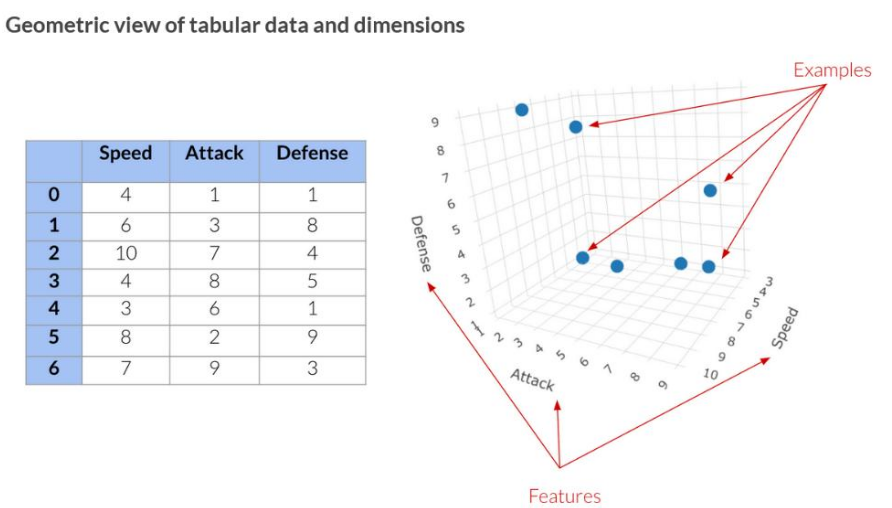


#### Dimensions in ML problems

- Dimensions $\approx$ 20: Low dimensional
- Dimensions $\approx$ 1000: Medium dimensional
- Dimensions $\approx$ 100,000: High dimensional


#### How do we calculate similarity between two points in high-dimensional space? 
- By calculating distance between them. Use Euclidian distance:
\begin{equation}
d(p, q) = \sqrt{\sum_{i=0}^n (p_i - q_i)^2}
\end{equation}

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [2]:
cities_df = pd.read_csv("../Data/canada_usa_cities.csv")
cities_df = cities_df.drop(columns=["Unnamed: 0"])
cities_df

,longitude,latitude,country
0,-69.7487,42.7266,USA
1,-115.6821,28.3843,USA
2,-74.6350,39.4678,USA
3,-139.1803,81.8543,Canada
4,-122.2292,49.2276,Canada
...,...,...,...
995,-136.4325,62.5985,Canada
996,-64.7426,49.1212,Canada
997,-92.1407,58.1173,Canada
998,-74.6859,28.4161,USA


In [3]:
train_df, test_df = train_test_split(cities_df, test_size=0.2, random_state=123)
train_df.head()

,longitude,latitude,country
512,-85.3314,29.0178,USA
685,-100.1331,58.7471,Canada
997,-92.1407,58.1173,Canada
927,-54.2626,74.5361,Canada
376,-109.6862,42.5132,USA


In [22]:
from sklearn.metrics.pairwise import euclidean_distances

In [5]:
two_cities = cities_df.sample(2, random_state=42).drop(columns='country') #pick two cities randomly
two_cities

,longitude,latitude
521,-77.1529,35.0511
737,-139.4082,81.5603


In [6]:
euclidean_distances(two_cities) #calculate euclidean distance between the two of them

array([[ 0.        , 77.70989681],
       [77.70989681,  0.        ]])

Finding the nearest neighboor

In [7]:
dists = euclidean_distances(train_df[["latitude", "longitude"]])
dists

array([[ 0.        , 33.21026349, 29.88557289, ..., 47.96352297,
        26.62479109, 13.92881844],
       [33.21026349,  0.        ,  8.01717567, ..., 25.11418772,
        31.87824937, 19.60004108],
       [29.88557289,  8.01717567,  0.        , ..., 20.99288106,
        35.10260355, 16.01739386],
       ...,
       [47.96352297, 25.11418772, 20.99288106, ...,  0.        ,
        55.96986193, 35.21167499],
       [26.62479109, 31.87824937, 35.10260355, ..., 55.96986193,
         0.        , 26.10974079],
       [13.92881844, 19.60004108, 16.01739386, ..., 35.21167499,
        26.10974079,  0.        ]], shape=(800, 800))

In [8]:
pd.DataFrame(dists).loc[:5, :5]

,0,1,2,3,4,5
0,0.000000,33.210263,29.885573,55.110670,27.843888,36.869221
1,33.210263,0.000000,8.017176,48.511806,18.836168,38.185983
2,29.885573,8.017176,0.000000,41.283501,23.480471,42.842157
3,55.110670,48.511806,41.283501,0.000000,64.009699,82.572174
4,27.843888,18.836168,23.480471,64.009699,0.000000,19.478377
5,36.869221,38.185983,42.842157,82.572174,19.478377,0.000000


In [9]:
#distance of each city to itself is gonna be 0 so we replace by infinity
np.fill_diagonal(dists, np.inf)
pd.DataFrame(dists).loc[:5, :5]

,0,1,2,3,4,5
0,inf,33.210263,29.885573,55.110670,27.843888,36.869221
1,33.210263,inf,8.017176,48.511806,18.836168,38.185983
2,29.885573,8.017176,inf,41.283501,23.480471,42.842157
3,55.110670,48.511806,41.283501,inf,64.009699,82.572174
4,27.843888,18.836168,23.480471,64.009699,inf,19.478377
5,36.869221,38.185983,42.842157,82.572174,19.478377,inf


#### Finding the nearest neighbour

In [12]:
train_df.iloc[0] # city 0

longitude   -85.3314
latitude     29.0178
country          USA
Name: 512, dtype: object

In [16]:
dists[0][:5]

array([        inf, 33.21026349, 29.88557289, 55.11067019, 27.84388809])

In [ ]:
np.argmin(dists[0]) # np.argmin returns the index of the minimum value in an array,

np.int64(64)

In [19]:
train_df.iloc[[64]] #this is the closest city to city 0

,longitude,latitude,country
280,-86.3475,28.9331,USA


In [ ]:
dists[0][64] #this is the euclidean distance

np.float64(1.0196240974000998)

#### Finding distances to a query point

In [23]:
query_point = [[-80, 25]]

In [25]:
dists = euclidean_distances(train_df[["longitude", "latitude"]], query_point)
dists[0:5]

array([[ 6.67581776],
       [39.29641808],
       [35.2725411 ],
       [55.82328333],
       [34.46712411]])

In [38]:
np.argmin(dists) # find the city closest to the query point by taking the index of city which has the smallest euclidean distance

np.int64(133)

In [39]:
train_df.iloc[133]

longitude   -80.8965
latitude     24.8584
country          USA
Name: 110, dtype: object

In [40]:
np.min(dists)

np.float64(0.907613800027086)

In [41]:
train_df.iloc[133][["longitude", "latitude"]]

longitude   -80.8965
latitude     24.8584
Name: 110, dtype: object

In [ ]:
dists[np.argmin(dists)] #distance between query point and closest city (can also just take min of dists)

array([0.9076138])

#### Use sklearn `NearestNeighbors`

In [50]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=1)
nn.fit(train_df[['longitude', 'latitude']])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [51]:
nn.kneighbors([[-80, 25]])

/home/sbron/ProductivityStudy/venv_prod/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


(array([[0.9076138]]), array([[133]]))

In [49]:
nn = NearestNeighbors(n_neighbors=10) #find 10 clostest cities
nn.fit(train_df[['longitude', 'latitude']])
nn.kneighbors([[-80, 25]])

/home/sbron/ProductivityStudy/venv_prod/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


(array([[0.9076138 , 1.73259488, 1.74776374, 2.1490553 , 2.17878439,
         2.82486382, 3.57062624, 3.58120914, 3.9472639 , 4.13456439]]),
 array([[133, 118,  60, 198, 311, 480, 372, 666,  75, 363]]))

### k-Nearest Neighbors (k-NNs) Classifier 

In [ ]:
small_train_df = cities_df.sample(30, random_state=90) #small sample of our cities sample
small_train_df

,longitude,latitude,country
221,-118.8170,28.3062,USA
825,-129.4503,74.4271,Canada
334,-76.2713,75.0916,Canada
982,-95.2861,33.6951,USA
42,-64.9114,41.9878,Canada
119,-70.3547,38.8293,USA
362,-126.2342,82.7344,Canada
250,-70.3777,40.1299,USA
588,-105.9337,42.8602,USA
608,-94.1213,43.4368,Canada


In [61]:
X_train = small_train_df.drop(columns='country')
y_train = small_train_df['country']

one_city = small_train_df.sample(1, random_state=30)
one_city

,longitude,latitude,country
83,-114.9707,57.643,Canada


In [66]:
import plotly.express as px
fig = px.scatter_geo(small_train_df, lat='latitude', lon='longitude', color='country')

# Add one_city as a separate trace on top
one_city_trace = px.scatter_geo(one_city, lat='latitude', lon='longitude').data[0]
one_city_trace.marker = dict(size=15, color='green', symbol='star')
fig.add_trace(one_city_trace)
fig.show()

In [69]:
from sklearn.neighbors import KNeighborsClassifier

for n in range(1, 20):
    neigh = KNeighborsClassifier(n_neighbors=n)
    neigh.fit(X_train, y_train)
    print(neigh.predict(one_city.drop(columns='country')))


['Canada']
['Canada']
['Canada']
['Canada']
['Canada']
['Canada']
['Canada']
['Canada']
['Canada']
['Canada']
['Canada']
['Canada']
['Canada']
['Canada']
['Canada']
['Canada']
['Canada']
['Canada']
['USA']


#### Check scores

In [75]:
X = cities_df.drop(columns='country')
y = cities_df['country']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train, y_train)
model.score(X_train, y_train), model.score(X_test, y_test)

(1.0, 0.91)

Do cross-validation

In [76]:
from sklearn.model_selection import cross_validate

k=1

knn1 = KNeighborsClassifier(n_neighbors=k)

scores = cross_validate(knn1, X_train, y_train, cv=5, return_train_score=True)

pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.005105,0.004546,0.91250,1.0
1,0.002204,0.003001,0.91250,1.0
2,0.001773,0.002315,0.89375,1.0
3,0.001692,0.002457,0.89375,1.0
4,0.001691,0.002307,0.92500,1.0


In [79]:
k=3

knn1 = KNeighborsClassifier(n_neighbors=k)

scores = cross_validate(knn1, X_train, y_train, cv=5, return_train_score=True)

pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.004087,0.004884,0.90000,0.945312
1,0.002386,0.003120,0.94375,0.957812
2,0.001654,0.002353,0.90000,0.956250
3,0.001582,0.002539,0.88750,0.956250
4,0.001613,0.002232,0.93125,0.951562


In [ ]:
# plot to see what's happening

results_dict = {
    "n_neighbors": list(),
    "mean_train_score": list(),
    "mean_cv_score": list()
                }

for k in range(1, 100):

    model = KNeighborsClassifier(n_neighbors=k)

    scores = cross_validate(model, X_train, y_train, cv=10, return_train_score=True)

    results_dict['n_neighbors'].append(k)
    results_dict['mean_train_score'].append(scores['train_score'].mean())
    results_dict['mean_cv_score'].append(scores['test_score'].mean())


df_scores = pd.DataFrame(results_dict)
df_scores.head()

,n_neighbors,mean_train_score,mean_cv_score
0,1,1.000000,0.90875
1,2,0.958889,0.89000
2,3,0.954167,0.91500
3,4,0.949583,0.90500
4,5,0.939306,0.91375


In [ ]:
df_scores.sort_values(by='mean_cv_score', ascending=False) 

,n_neighbors,mean_train_score,mean_cv_score
10,11,0.930556,0.92250
55,56,0.919444,0.92250
8,9,0.928611,0.92125
13,14,0.928750,0.92125
47,48,0.920556,0.92000
...,...,...,...
92,93,0.892222,0.89125
1,2,0.958889,0.89000
90,91,0.894583,0.89000
94,95,0.891250,0.88875


Best score is when n_neighbors=11. Smaller = ovefitting, larger = underfitting

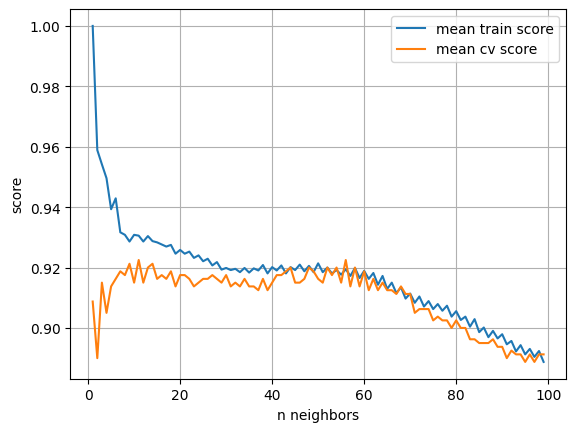

In [89]:
import matplotlib.pyplot as plt

plt.plot(df_scores['n_neighbors'], df_scores['mean_train_score'], label='mean train score')
plt.plot(df_scores['n_neighbors'], df_scores['mean_cv_score'], label='mean cv score')
plt.legend()
plt.xlabel('n neighbors')
plt.ylabel('score')
plt.grid()

/home/sbron/ProductivityStudy/venv_prod/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


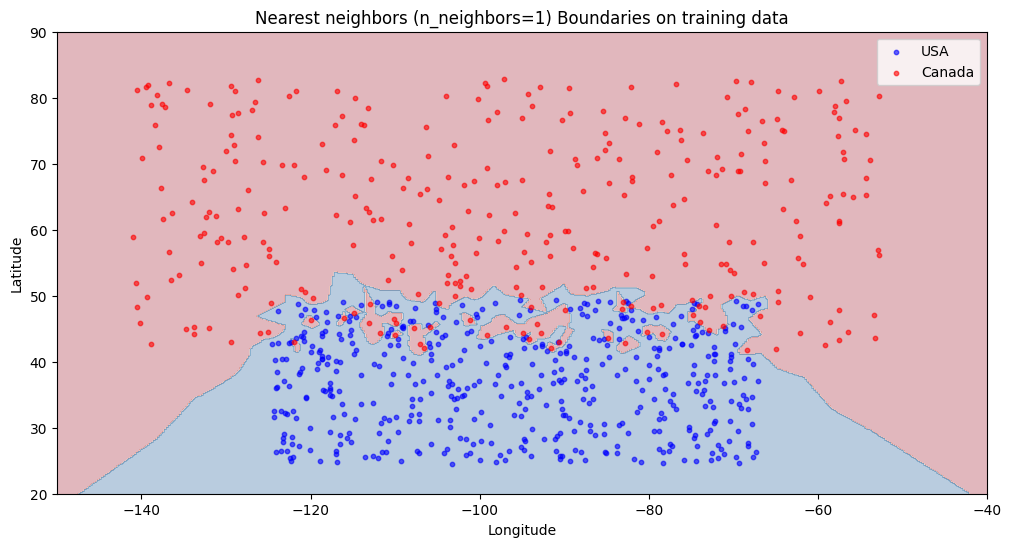

In [97]:
# Create a mesh grid over the lon/lat range
xx, yy = np.meshgrid(
    np.linspace(-150, -40, 500),
    np.linspace(20, 90, 500)
)

model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train, y_train)
# Predict on every point in the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = (Z == 'USA').astype(int).reshape(xx.shape)  # convert to 0/1 for plotting

# Plot the boundary
plt.figure(figsize=(12, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')  # filled regions

# Plot the actual data points on top
for country, color in [('USA', 'blue'), ('Canada', 'red')]:
    mask = train_df['country'] == country
    plt.scatter(train_df[mask]['longitude'], train_df[mask]['latitude'],
                c=color, s=10, alpha=0.6, label=country)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.title('Nearest neighbors (n_neighbors=1) Boundaries on training data')
plt.show()

/home/sbron/ProductivityStudy/venv_prod/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


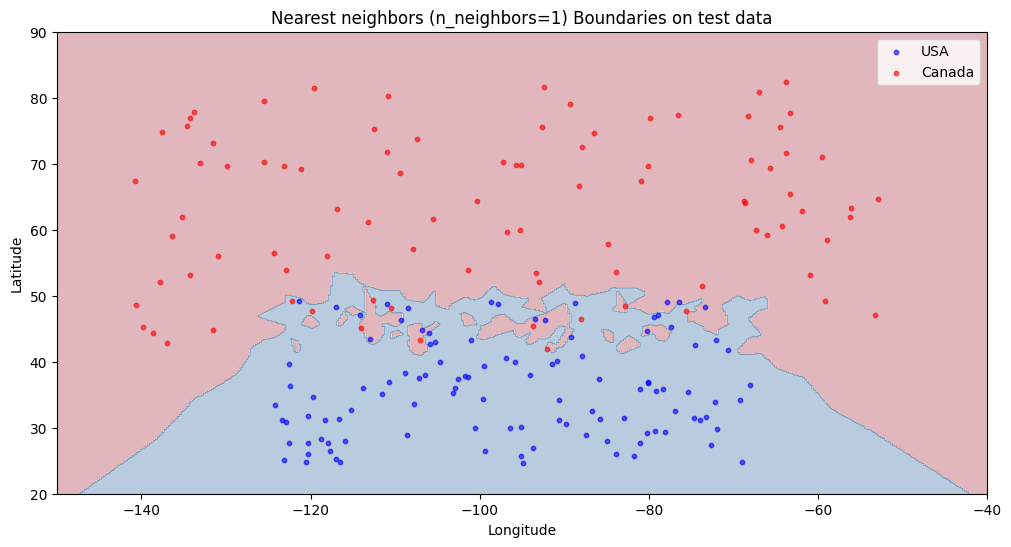

In [96]:
# Create a mesh grid over the lon/lat range
xx, yy = np.meshgrid(
    np.linspace(-150, -40, 500),
    np.linspace(20, 90, 500)
)

model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train, y_train)
# Predict on every point in the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = (Z == 'USA').astype(int).reshape(xx.shape)  # convert to 0/1 for plotting

# Plot the boundary
plt.figure(figsize=(12, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')  # filled regions

# Plot the actual data points on top
for country, color in [('USA', 'blue'), ('Canada', 'red')]:
    mask = test_df['country'] == country
    plt.scatter(test_df[mask]['longitude'], test_df[mask]['latitude'],
                c=color, s=10, alpha=0.6, label=country)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.title('Nearest neighbors (n_neighbors=1) Boundaries on test data')
plt.show()

/home/sbron/ProductivityStudy/venv_prod/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


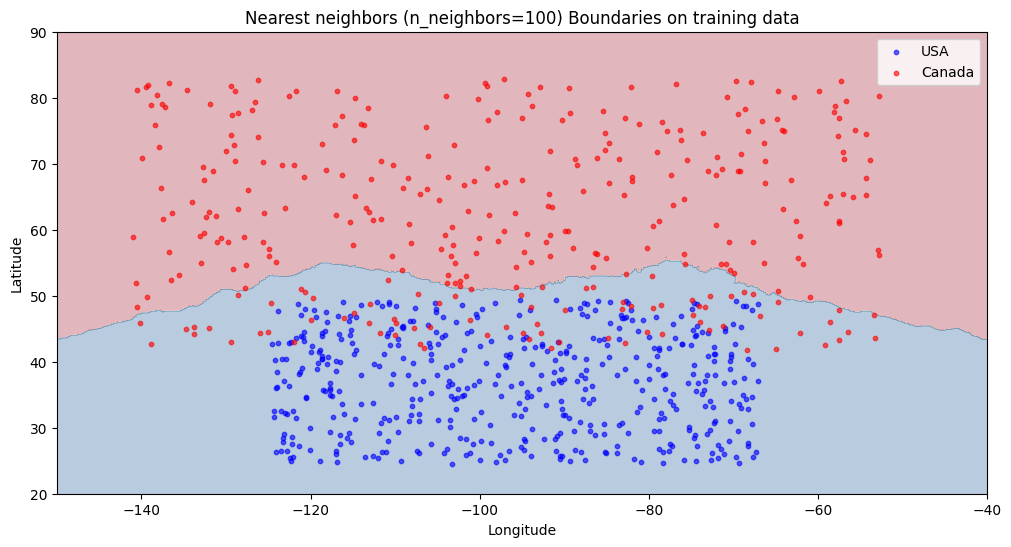

In [98]:
# Create a mesh grid over the lon/lat range
xx, yy = np.meshgrid(
    np.linspace(-150, -40, 500),
    np.linspace(20, 90, 500)
)

model = KNeighborsClassifier(n_neighbors=100)
model.fit(X_train, y_train)
# Predict on every point in the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = (Z == 'USA').astype(int).reshape(xx.shape)  # convert to 0/1 for plotting

# Plot the boundary
plt.figure(figsize=(12, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')  # filled regions

# Plot the actual data points on top
for country, color in [('USA', 'blue'), ('Canada', 'red')]:
    mask = train_df['country'] == country
    plt.scatter(train_df[mask]['longitude'], train_df[mask]['latitude'],
                c=color, s=10, alpha=0.6, label=country)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.title('Nearest neighbors (n_neighbors=100) Boundaries on training data')
plt.show()

/home/sbron/ProductivityStudy/venv_prod/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


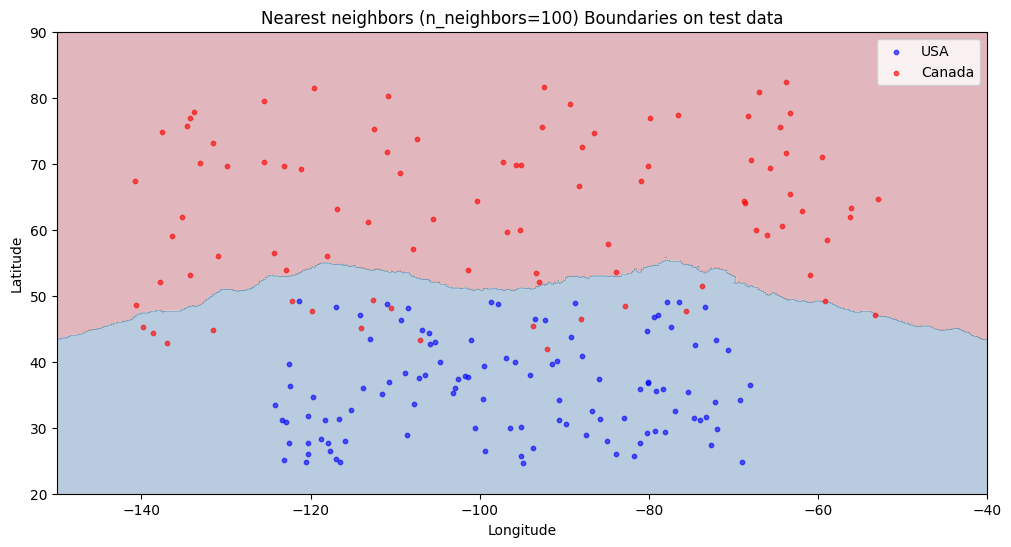

In [99]:
# Create a mesh grid over the lon/lat range
xx, yy = np.meshgrid(
    np.linspace(-150, -40, 500),
    np.linspace(20, 90, 500)
)

model = KNeighborsClassifier(n_neighbors=100)
model.fit(X_train, y_train)
# Predict on every point in the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = (Z == 'USA').astype(int).reshape(xx.shape)  # convert to 0/1 for plotting

# Plot the boundary
plt.figure(figsize=(12, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')  # filled regions

# Plot the actual data points on top
for country, color in [('USA', 'blue'), ('Canada', 'red')]:
    mask = test_df['country'] == country
    plt.scatter(test_df[mask]['longitude'], test_df[mask]['latitude'],
                c=color, s=10, alpha=0.6, label=country)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.title('Nearest neighbors (n_neighbors=100) Boundaries on test data')
plt.show()

/home/sbron/ProductivityStudy/venv_prod/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


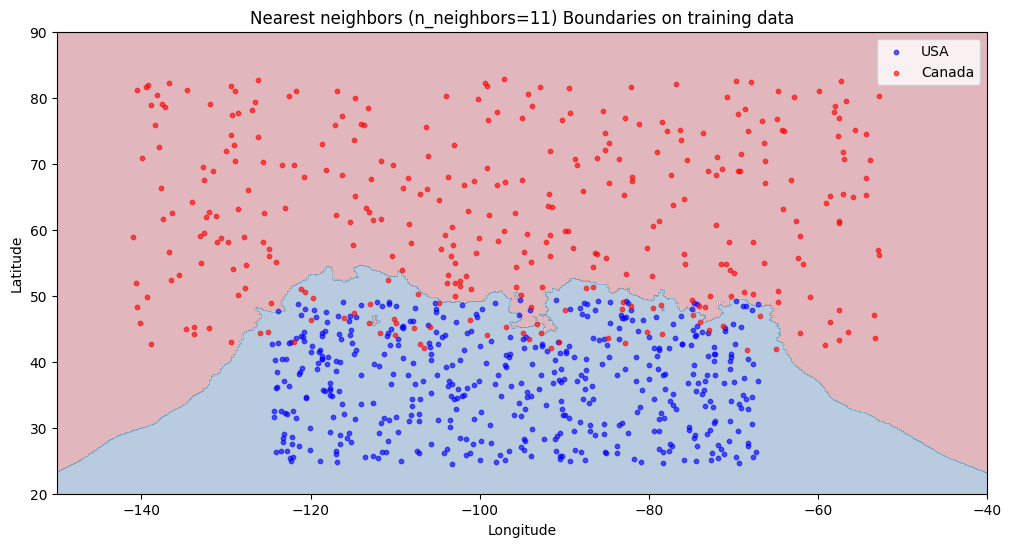

In [100]:
# Create a mesh grid over the lon/lat range
xx, yy = np.meshgrid(
    np.linspace(-150, -40, 500),
    np.linspace(20, 90, 500)
)

model = KNeighborsClassifier(n_neighbors=11)
model.fit(X_train, y_train)
# Predict on every point in the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = (Z == 'USA').astype(int).reshape(xx.shape)  # convert to 0/1 for plotting

# Plot the boundary
plt.figure(figsize=(12, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')  # filled regions

# Plot the actual data points on top
for country, color in [('USA', 'blue'), ('Canada', 'red')]:
    mask = train_df['country'] == country
    plt.scatter(train_df[mask]['longitude'], train_df[mask]['latitude'],
                c=color, s=10, alpha=0.6, label=country)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.title('Nearest neighbors (n_neighbors=11) Boundaries on training data')
plt.show()

/home/sbron/ProductivityStudy/venv_prod/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


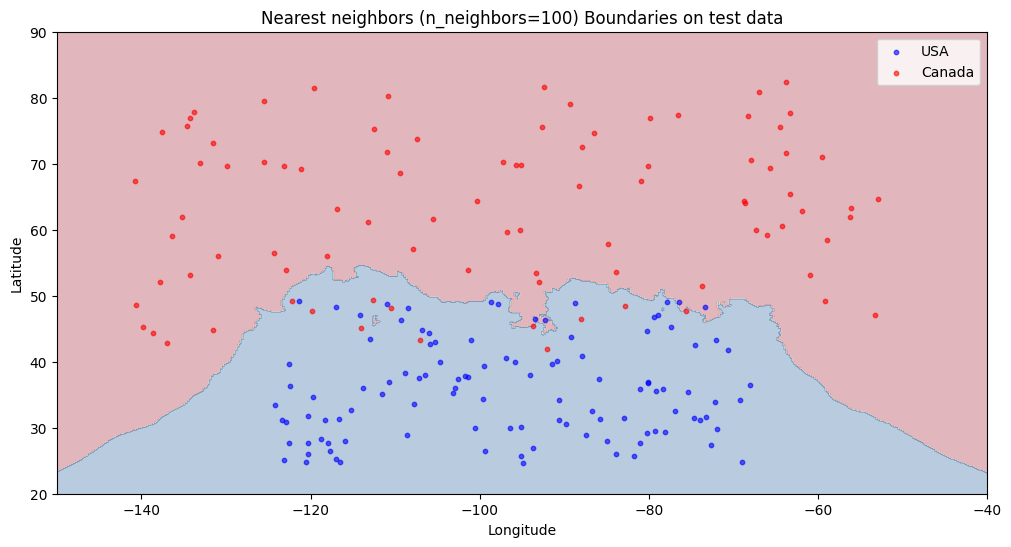

In [101]:
# Create a mesh grid over the lon/lat range
xx, yy = np.meshgrid(
    np.linspace(-150, -40, 500),
    np.linspace(20, 90, 500)
)

model = KNeighborsClassifier(n_neighbors=11)
model.fit(X_train, y_train)
# Predict on every point in the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = (Z == 'USA').astype(int).reshape(xx.shape)  # convert to 0/1 for plotting

# Plot the boundary
plt.figure(figsize=(12, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')  # filled regions

# Plot the actual data points on top
for country, color in [('USA', 'blue'), ('Canada', 'red')]:
    mask = test_df['country'] == country
    plt.scatter(test_df[mask]['longitude'], test_df[mask]['latitude'],
                c=color, s=10, alpha=0.6, label=country)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.title('Nearest neighbors (n_neighbors=100) Boundaries on test data')
plt.show()

We know the best value of the hyperparameter n_neighbors=11. Now we can assess model on the test set

In [105]:
knn = KNeighborsClassifier(n_neighbors=11)

knn.fit(X_train, y_train)

knn.predict(X_test)

knn.score(X_test, y_test)

0.925

### K-Nearest Neighbors Regressor